# Rede de Visibilidade a partir de Dados do INMET — Fortaleza (A304)

**Trabalho computacional — Análise de Redes Complexas**

Estação A304 (Fortaleza-CE), utilizando a série de **temperatura máxima diária** como série temporal de entrada de redes de visibilidade.

**Parte I — Preparação dos dados e criação da rede**
1. Coleta, padronização e agregação dos dados horários do INMET.
2. Diagnóstico de completude da série.
3. Detecção dos eventos CTX90pct e EHF.
4. Recorte principal para 2008–2021 e tratamento da falha curta de dezembro de 2014.
5. Construção do HVG e do NVG com `ts2vg`.
6. Acoplamento dos metadados climáticos aos nós.
7. Validação do HVG com o modelo nulo i.i.d. de Luque et al. (2009).

**Parte II — Análise estrutural da rede**
1. Tamanho, densidade e componentes conexos.
2. Distribuição de graus.
3. Transitividade e agrupamento local.
4. Distâncias geodésicas.
5. Cruzamento dos Top 15 hubs do HVG com as ondas de calor.

As análises de visibilidade são apresentadas para **HVG** (*Horizontal Visibility Graph*) e **NVG** (*Natural Visibility Graph*), com HVG como rede principal no cruzamento com os eventos.

## 1 · Imports, diretórios e padrão visual

In [1]:
!pip install fastparquet -q
!pip install ts2vg -q

import io
import zipfile
import warnings
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

from scipy import stats as sp_stats
from tqdm import tqdm
from ts2vg import HorizontalVG, NaturalVG

warnings.filterwarnings("ignore")

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
PLOTS_DIR = Path("data/plots")

for diretorio in (RAW_DIR, PROCESSED_DIR, PLOTS_DIR):
    diretorio.mkdir(parents=True, exist_ok=True)

STATION_CODE = "A304"
ANOS = list(range(2003, 2024))
BASE_URL = "https://portal.inmet.gov.br/uploads/dadoshistoricos/{ano}.zip"

# ==========================================================================
FUNDO  = '#ffffff'
CARTA  = '#ffffff'
BORDA  = '#333333'
TEXTO  = '#000000'
CINZA  = '#555555'

AZUL   = '#1f77b4'
LARANJA= '#ff7f0e'
VERDE  = '#2ca02c'
ROXO   = '#9467bd'

CORES_REDE = {
    "HVG": AZUL,
    "NVG": ROXO,
}

plt.rcParams.update({
    "figure.facecolor": FUNDO,
    "axes.facecolor": CARTA,
    "axes.edgecolor": BORDA,
    "axes.labelcolor": CINZA,
    "xtick.color": CINZA,
    "ytick.color": CINZA,
    "text.color": TEXTO,
    "grid.color": BORDA,
    "grid.linewidth": 0.5,
    "legend.facecolor": CARTA,
    "legend.edgecolor": BORDA,
    "legend.labelcolor": TEXTO,
    "savefig.facecolor": FUNDO,
    "savefig.bbox": "tight",
    "svg.fonttype": "none",
})

def estilizar_ax(ax):
    ax.set_facecolor(CARTA)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDA)
    ax.tick_params(colors=CINZA, labelsize=9)
    ax.xaxis.label.set_color(CINZA)
    ax.yaxis.label.set_color(CINZA)
    ax.grid(True, color=BORDA, linewidth=0.5, alpha=0.7)

def salvar_mostrar(fig, nome_arquivo):
    fig.savefig(PLOTS_DIR / nome_arquivo, dpi=160)
    plt.show()
    plt.close(fig)
# ==========================================================================

## 2 · Dados do INMET
Padronizando as colunas e valores inválidos convertidos para 'NaN'.

Salvando as observações horárias agregadas em escala diária


In [2]:
_horario_path = PROCESSED_DIR / "fortaleza_horario.parquet"
_diario_path  = PROCESSED_DIR / "fortaleza_diario.parquet"

def download_ano(ano: int) -> pd.DataFrame | None:
    url = BASE_URL.format(ano=ano)
    destino_csv = RAW_DIR / f"inmet_{STATION_CODE}_{ano}.csv"

    if destino_csv.exists():
        try:
            return pd.read_csv(
                destino_csv,
                sep=";",
                encoding="utf-8",
                skiprows=8
            )
        except Exception:
            return pd.read_csv(
                destino_csv,
                sep=";",
                encoding="latin-1",
                skiprows=8
            )

    try:
        resposta = requests.get(url, timeout=120)
        resposta.raise_for_status()
    except requests.exceptions.RequestException as erro:
        print(f"  [{ano}] ERRO no download: {erro}")
        return None

    with zipfile.ZipFile(io.BytesIO(resposta.content)) as arquivo_zip:
        arquivos_estacao = [
            nome for nome in arquivo_zip.namelist()
            if STATION_CODE in nome.upper()
        ]

        if not arquivos_estacao:
            print(f"  [{ano}] Estação {STATION_CODE} não encontrada.")
            return None

        with arquivo_zip.open(arquivos_estacao[0]) as arquivo:
            conteudo = arquivo.read().decode("latin-1")

        destino_csv.write_text(conteudo, encoding="utf-8")

        return pd.read_csv(
            io.StringIO(conteudo),
            sep=";",
            skiprows=8,
            encoding="utf-8"
        )


def padronizar_colunas(df: pd.DataFrame) -> pd.DataFrame:
    mapeamento = {}

    for coluna in df.columns:
        c = coluna.upper().strip()

        if c.startswith("DATA"):
            mapeamento[coluna] = "data"
        elif c.startswith("HORA"):
            mapeamento[coluna] = "hora_utc"
        elif "TEMPERATURA" in c and "ORVALHO" not in c:
            if "XIMA" in c:
                mapeamento[coluna] = "temp_max"
            elif "NIMA" in c:
                mapeamento[coluna] = "temp_min"
            else:
                mapeamento[coluna] = "temp_ar"
        elif "UMIDADE RELATIVA" in c and ("HORARIA" in c or "HORÁRIA" in c):
            mapeamento[coluna] = "umidade"
        elif "PRECIPITA" in c:
            mapeamento[coluna] = "precipitacao"
        elif "PRESS" in c and "ESTA" in c:
            mapeamento[coluna] = "pressao"
        elif "VENTO" in c and "VELOCIDADE" in c:
            mapeamento[coluna] = "vento_vel"
        elif "VENTO" in c and "DIRE" in c:
            mapeamento[coluna] = "vento_dir"
        elif "RADIA" in c and "GLOBAL" in c:
            mapeamento[coluna] = "radiacao"

    df = df.rename(columns=mapeamento)
    df = df.loc[:, ~df.columns.duplicated()]

    colunas_alvo = [
        "data", "hora_utc", "temp_ar", "temp_max", "temp_min",
        "umidade", "precipitacao", "pressao", "vento_vel",
        "vento_dir", "radiacao"
    ]

    return df[[c for c in colunas_alvo if c in df.columns]].copy()


def tratar_valores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df.replace(
        {9999: np.nan, -9999: np.nan, "9999": np.nan, "-9999": np.nan},
        inplace=True
    )

    numericas = [
        "temp_ar", "temp_max", "temp_min", "umidade",
        "precipitacao", "pressao", "vento_vel",
        "vento_dir", "radiacao"
    ]

    for coluna in numericas:
        if coluna in df.columns:
            df[coluna] = (
                df[coluna]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .replace("nan", np.nan)
            )
            df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

    if "data" in df.columns and "hora_utc" in df.columns:
        datas_limpas = pd.to_datetime(
            df["data"].astype(str),
            errors="coerce"
        )

        horas_limpas = (
            df["hora_utc"]
            .astype(str)
            .str.replace(":", "", regex=False)
            .str.zfill(4)
            .str[:2]
        )

        horas_delta = pd.to_timedelta(
            pd.to_numeric(horas_limpas, errors="coerce"),
            unit="h"
        )

        df["datetime_utc"] = datas_limpas + horas_delta
        df["datetime_brt"] = df["datetime_utc"] - pd.Timedelta(hours=3)

        df.drop(
            columns=["data", "hora_utc", "datetime_utc"],
            inplace=True
        )

    return df


def coletar_serie_historica(anos: list[int]) -> pd.DataFrame:
    frames = []

    for ano in tqdm(anos, desc="Processando"):
        df_ano = download_ano(ano)

        if df_ano is None:
            continue

        df_ano = padronizar_colunas(df_ano)
        df_ano = tratar_valores(df_ano)

        n = (
            df_ano["temp_ar"].notna().sum()
            if "temp_ar" in df_ano.columns
            else len(df_ano)
        )

        print(f"  → Ano {ano}: {n} leituras de temperatura resgatadas.")
        frames.append(df_ano)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def agregar_diario(df_horario: pd.DataFrame) -> pd.DataFrame:
    df = df_horario.copy()
    df["data"] = df["datetime_brt"].dt.normalize()

    return (
        df.groupby("data")
        .agg(
            temp_max=("temp_ar", "max"),
            temp_min=("temp_ar", "min"),
            temp_media=("temp_ar", "mean"),
            umidade_med=("umidade", "mean"),
            pressao_med=("pressao", "mean"),
            vento_med=("vento_vel", "mean"),
            prec_total=("precipitacao", "sum"),
        )
        .reset_index()
    )

# ==========================================================================
if _horario_path.exists() and _diario_path.exists():
    print("Dados processados já existem localmente em data/processed/ -- PULA DOWNLOAD E TRATAMENTO INTEGRAL.")
    serie_horaria = pd.read_parquet(_horario_path)
    serie_diaria  = pd.read_parquet(_diario_path)
    print(f"✓ Dados horários carregados com sucesso: {len(serie_horaria):,} registros.")
    print(f"✓ Dados diários carregados com sucesso : {len(serie_diaria):,} dias.")
else:
    print(f"\n{'='*60}")
    print(f"  PROCESSAMENTO INMET — ESTAÇÃO {STATION_CODE} (FORTALEZA-CE)")
    print(f"  Anos: {ANOS[0]}–{ANOS[-1]}")
    print(f"{'='*60}\n")

    serie_horaria = coletar_serie_historica(ANOS)
    serie_diaria = agregar_diario(serie_horaria)

    serie_horaria.to_parquet(_horario_path, engine="fastparquet", index=False)
    serie_diaria.to_parquet(_diario_path, engine="fastparquet", index=False)

    print(f"\n✓ Dados horários: {len(serie_horaria):,} registros salvos.")
    print(f"✓ Dados diários : {len(serie_diaria):,} dias salvos com sucesso.")
    if not serie_diaria.empty:
        print(
            f"✓ Período       : "
            f"{serie_diaria['data'].min()} → {serie_diaria['data'].max()}"
        )
# ==========================================================================

Dados processados já existem localmente em data/processed/ -- PULA DOWNLOAD E TRATAMENTO INTEGRAL.
✓ Dados horários carregados com sucesso: 182,784 registros.
✓ Dados diários carregados com sucesso : 7,617 dias.


## 3 · Diagnóstico de completude e falhas

Reindexando um calendário diário completo para localizar dias ausentes e blocos de falhas.

In [3]:
diario_vg = pd.read_parquet(PROCESSED_DIR / "fortaleza_diario.parquet")
diario_vg["data"] = pd.to_datetime(diario_vg["data"])
diario_vg = diario_vg.sort_values("data").reset_index(drop=True)

calendario_completo = pd.date_range(
    diario_vg["data"].min(),
    diario_vg["data"].max(),
    freq="D"
)

diario_vg = (
    diario_vg
    .set_index("data")
    .reindex(calendario_completo)
    .rename_axis("data")
    .reset_index()
)

print(f"\n{'='*60}")
print("  DIAGNÓSTICO DE COMPLETUDE — TEMP_MAX")
print(f"{'='*60}\n")
print(
    f"Período: {calendario_completo.min().date()} "
    f"→ {calendario_completo.max().date()}"
)
print(f"Dias no calendário: {len(calendario_completo)}")
print(
    f"Dias com temp_max válido: "
    f"{diario_vg['temp_max'].notna().sum()} "
    f"({diario_vg['temp_max'].notna().mean()*100:.2f}%)"
)
print(
    f"Dias com temp_max faltante: "
    f"{diario_vg['temp_max'].isna().sum()} "
    f"({diario_vg['temp_max'].isna().mean()*100:.2f}%)"
)

resumo_ano = (
    diario_vg.assign(ano=diario_vg["data"].dt.year)
    .groupby("ano")["temp_max"]
    .apply(lambda s: s.notna().mean() * 100)
    .round(1)
)

print("\nCompletude de temp_max por ano:")
for ano, percentual in resumo_ano.items():
    marcador = "  <-- atenção" if percentual < 90 else ""
    print(f"  {ano}: {percentual:5.1f}%{marcador}")

falha = diario_vg["temp_max"].isna()
grupo_falha = (falha != falha.shift()).cumsum()

gaps = (
    diario_vg[falha]
    .assign(grupo=grupo_falha[falha])
    .groupby("grupo")
    .agg(
        inicio=("data", "min"),
        fim=("data", "max"),
        tamanho=("data", "size")
    )
    .sort_values("tamanho", ascending=False)
    .reset_index(drop=True)
)

print(f"\nTotal de blocos de falha (gaps): {len(gaps)}")

if not gaps.empty:
    print("\nDistribuição do tamanho dos gaps:")
    print(f"  1 dia    : {(gaps['tamanho'] == 1).sum()}")
    print(
        f"  2–3 dias : "
        f"{((gaps['tamanho'] >= 2) & (gaps['tamanho'] <= 3)).sum()}"
    )
    print(
        f"  4–7 dias : "
        f"{((gaps['tamanho'] >= 4) & (gaps['tamanho'] <= 7)).sum()}"
    )
    print(f"  >7 dias  : {(gaps['tamanho'] > 7).sum()}")

    print("\nOs 10 maiores gaps:")
    print(gaps.head(10).to_string(index=False))

gaps.to_csv(
    PROCESSED_DIR / "diagnostico_gaps_temp_max.csv",
    index=False
)


  DIAGNÓSTICO DE COMPLETUDE — TEMP_MAX

Período: 2003-02-23 → 2023-12-31
Dias no calendário: 7617
Dias com temp_max válido: 7021 (92.18%)
Dias com temp_max faltante: 596 (7.82%)

Completude de temp_max por ano:
  2003:  77.2%  <-- atenção
  2004:  78.4%  <-- atenção
  2005:  57.8%  <-- atenção
  2006:  77.5%  <-- atenção
  2007:  81.4%  <-- atenção
  2008: 100.0%
  2009: 100.0%
  2010: 100.0%
  2011: 100.0%
  2012: 100.0%
  2013: 100.0%
  2014:  96.4%
  2015: 100.0%
  2016: 100.0%
  2017: 100.0%
  2018: 100.0%
  2019: 100.0%
  2020: 100.0%
  2021: 100.0%
  2022:  89.6%  <-- atenção
  2023:  75.1%  <-- atenção

Total de blocos de falha (gaps): 20

Distribuição do tamanho dos gaps:
  1 dia    : 6
  2–3 dias : 1
  4–7 dias : 2
  >7 dias  : 11

Os 10 maiores gaps:
    inicio        fim  tamanho
2004-11-27 2005-04-25      150
2005-11-23 2006-03-18      116
2007-03-18 2007-05-24       68
2023-10-27 2023-12-31       66
2003-12-06 2004-01-30       56
2003-07-15 2003-08-28       45
2022-11-21 

## 4 · Detecção de ondas de calor

- **CTX90pct**
- **EHF (Excess Heat Factor)**

In [4]:
def calcular_percentis_diarios(
    df,
    coluna,
    percentil=90,
    janela_dias=15,
    ano_ref_ini=2003,
    ano_ref_fim=2017
):
    df_ref = df[
        (df["data"].dt.year >= ano_ref_ini) &
        (df["data"].dt.year <= ano_ref_fim)
    ].copy()

    df_ref["dia_do_ano"] = df_ref["data"].dt.dayofyear

    janelas = {
        dia: {
            ((d - 1) % 366) + 1
            for d in range(
                dia - janela_dias,
                dia + janela_dias + 1
            )
        }
        for dia in range(1, 367)
    }

    resultado = {}

    for dia, dias_janela in janelas.items():
        mascara = df_ref["dia_do_ano"].isin(dias_janela)
        valores = df_ref.loc[mascara, coluna].dropna()

        resultado[dia] = (
            np.percentile(valores, percentil)
            if len(valores) > 0
            else np.nan
        )

    return pd.Series(
        resultado,
        name=f"p{int(percentil)}_{coluna}"
    )


def detectar_ctx90pct(df, percentis, min_dias=3):
    df = df.copy().sort_values("data").reset_index(drop=True)

    df["dia_do_ano"] = df["data"].dt.dayofyear
    df["p90_tmax"] = df["dia_do_ano"].map(percentis)
    df["excede_p90"] = df["temp_max"] > df["p90_tmax"]

    df["grupo"] = (
        df["excede_p90"] != df["excede_p90"].shift()
    ).cumsum()

    grupos_validos = (
        df[df["excede_p90"]]
        .groupby("grupo")
        .filter(lambda g: len(g) >= min_dias)["grupo"]
        .unique()
    )

    df["onda_ctx90"] = (
        df["grupo"].isin(grupos_validos) &
        df["excede_p90"]
    )

    mapeamento_ids = {
        grupo: i + 1
        for i, grupo in enumerate(grupos_validos)
    }

    df["id_evento_ctx90"] = (
        df["grupo"]
        .map(mapeamento_ids)
        .fillna(0)
        .astype(int)
    )

    df.loc[~df["onda_ctx90"], "id_evento_ctx90"] = 0

    return df.drop(columns=["grupo"])


def calcular_ehf(df, p95_serie):
    df = df.copy().sort_values("data").reset_index(drop=True)

    temperatura_media = df["temp_media"]

    T3 = temperatura_media.rolling(
        window=3,
        min_periods=1
    ).mean()

    T30 = (
        temperatura_media
        .shift(3)
        .rolling(window=30, min_periods=1)
        .mean()
    )

    df["EHIsig"] = T3 - p95_serie
    df["EHIaccl"] = T3 - T30
    df["EHF"] = (
        df["EHIsig"] *
        np.maximum(1, df["EHIaccl"])
    )

    df.loc[df["EHIsig"] <= 0, "EHF"] = 0.0

    return df


def detectar_ehf(df, min_dias=3):
    df = df.copy()

    df["positivo_ehf"] = (
        (df["EHIsig"] > 0) &
        (df["EHF"] > 0)
    )

    df["grupo_ehf"] = (
        df["positivo_ehf"] !=
        df["positivo_ehf"].shift()
    ).cumsum()

    grupos_validos = (
        df[df["positivo_ehf"]]
        .groupby("grupo_ehf")
        .filter(lambda g: len(g) >= min_dias)["grupo_ehf"]
        .unique()
    )

    df["onda_ehf"] = (
        df["grupo_ehf"].isin(grupos_validos) &
        df["positivo_ehf"]
    )

    mapeamento_ids = {
        grupo: i + 1
        for i, grupo in enumerate(grupos_validos)
    }

    df["id_evento_ehf"] = (
        df["grupo_ehf"]
        .map(mapeamento_ids)
        .fillna(0)
        .astype(int)
    )

    df.loc[~df["onda_ehf"], "id_evento_ehf"] = 0

    return df.drop(columns=["grupo_ehf"])


def resumir_eventos(
    df,
    col_evento,
    col_id,
    col_intensidade="temp_max"
):
    colunas_vazias = [
        "id_evento", "data_inicio", "data_fim",
        "duracao_dias", "intensidade_max",
        "intensidade_media", "ano", "mes_inicio"
    ]

    eventos = []

    if col_evento in df.columns and col_id in df.columns:
        for evento_id, grupo in df[df[col_evento]].groupby(col_id):
            if evento_id == 0:
                continue

            eventos.append({
                "id_evento": int(evento_id),
                "data_inicio": grupo["data"].min(),
                "data_fim": grupo["data"].max(),
                "duracao_dias": len(grupo),
                "intensidade_max": grupo[col_intensidade].max(),
                "intensidade_media": grupo[col_intensidade].mean(),
                "ano": grupo["data"].dt.year.iloc[0],
                "mes_inicio": grupo["data"].dt.month.iloc[0],
            })

    if not eventos:
        return pd.DataFrame(columns=colunas_vazias)

    return (
        pd.DataFrame(eventos)
        .sort_values("data_inicio")
        .reset_index(drop=True)
    )

# ==========================================================================

diario = pd.read_parquet(PROCESSED_DIR / "fortaleza_diario.parquet")
diario["data"] = pd.to_datetime(diario["data"])

ANO_REF_INI = 2003
ANO_REF_FIM = 2017

print(f"\n{'='*60}")
print("  DETECÇÃO DE ONDAS DE CALOR — FORTALEZA-CE")
print(f"{'='*60}")

p90_tmax = calcular_percentis_diarios(
    diario,
    "temp_max",
    percentil=90,
    ano_ref_ini=ANO_REF_INI,
    ano_ref_fim=ANO_REF_FIM
)

p95_tmedia = diario.loc[
    (diario["data"].dt.year >= ANO_REF_INI) &
    (diario["data"].dt.year <= ANO_REF_FIM),
    "temp_media"
].quantile(0.95)

print(
    f"P90(Tmax) médio no período de referência: "
    f"{p90_tmax.mean():.2f} °C"
)
print(
    f"P95(Tmédia) no período de referência: "
    f"{p95_tmedia:.2f} °C"
)

diario = detectar_ctx90pct(diario, p90_tmax)
eventos_ctx = resumir_eventos(
    diario,
    "onda_ctx90",
    "id_evento_ctx90",
    "temp_max"
)

print(f"\nCTX90pct — eventos detectados: {len(eventos_ctx)}")
if not eventos_ctx.empty:
    print(
        f"Duração média: "
        f"{eventos_ctx['duracao_dias'].mean():.1f} dias"
    )

diario = calcular_ehf(diario, p95_tmedia)
diario = detectar_ehf(diario)

eventos_ehf = resumir_eventos(
    diario,
    "onda_ehf",
    "id_evento_ehf",
    "EHF"
)

print(f"EHF — eventos detectados: {len(eventos_ehf)}")
if not eventos_ehf.empty:
    print(
        f"Duração média: "
        f"{eventos_ehf['duracao_dias'].mean():.1f} dias"
    )

diario.to_parquet(
    PROCESSED_DIR / "fortaleza_ondas_detectadas.parquet",
    engine="fastparquet",
    index=False
)

eventos_ctx.to_csv(
    PROCESSED_DIR / "eventos_ctx90pct.csv",
    index=False
)

eventos_ehf.to_csv(
    PROCESSED_DIR / "eventos_ehf.csv",
    index=False
)
# ==========================================================================


  DETECÇÃO DE ONDAS DE CALOR — FORTALEZA-CE
P90(Tmax) médio no período de referência: 29.90 °C
P95(Tmédia) no período de referência: 28.23 °C

CTX90pct — eventos detectados: 59
Duração média: 4.2 dias
EHF — eventos detectados: 66
Duração média: 8.2 dias


## 5 · Recorte temporal e tratamento da falha

O período principal da análise é **2008–2021**

In [5]:
diario = pd.read_parquet(
    PROCESSED_DIR / "fortaleza_diario.parquet"
)
diario["data"] = pd.to_datetime(diario["data"])

calendario_recorte = pd.date_range(
    "2008-01-01",
    "2021-12-31",
    freq="D"
)

df_recorte = (
    diario
    .set_index("data")
    .reindex(calendario_recorte)
    .rename_axis("data")
    .reset_index()
)

print(f"Dias no recorte 2008–2021: {len(df_recorte)}")
print(
    f"NaNs em temp_max antes da interpolação: "
    f"{df_recorte['temp_max'].isna().sum()}"
)

df_recorte["temp_max"] = (
    df_recorte["temp_max"]
    .interpolate(method="linear")
)

print(
    f"NaNs em temp_max após a interpolação: "
    f"{df_recorte['temp_max'].isna().sum()}"
)

if df_recorte["temp_max"].isna().any():
    raise ValueError(
        "A série ainda contém NaN após a interpolação; "
        "o Visibility Graph não deve ser construído."
    )

serie_temp_max = df_recorte["temp_max"].to_numpy(
    dtype=np.float64
)

Dias no recorte 2008–2021: 5114
NaNs em temp_max antes da interpolação: 13
NaNs em temp_max após a interpolação: 0


## 6 · Construção dos Visibility Graphs

A mesma série tratada é convertida em dois grafos:

**HVG**, usando `HorizontalVG`

**NVG**, usando `NaturalVG`.

Cada nó recebe a data, a temperatura máxima e as duas flags binárias de onda de calor.

In [6]:
print(f"\n{'='*60}")
print("  CONSTRUÇÃO DOS GRAFOS DE VISIBILIDADE")
print(f"{'='*60}")

hvg = HorizontalVG()
hvg.build(serie_temp_max)
G_hvg = hvg.as_networkx()

nvg = NaturalVG()
nvg.build(serie_temp_max)
G_nvg = nvg.as_networkx()

eventos_ctx = pd.read_csv(
    PROCESSED_DIR / "eventos_ctx90pct.csv",
    parse_dates=["data_inicio", "data_fim"]
)

eventos_ehf = pd.read_csv(
    PROCESSED_DIR / "eventos_ehf.csv",
    parse_dates=["data_inicio", "data_fim"]
)

dias_ctx = set()
for _, evento in eventos_ctx.iterrows():
    dias_ctx.update(
        pd.date_range(
            evento["data_inicio"],
            evento["data_fim"]
        ).date
    )

dias_ehf = set()
for _, evento in eventos_ehf.iterrows():
    dias_ehf.update(
        pd.date_range(
            evento["data_inicio"],
            evento["data_fim"]
        ).date
    )

# Atributos dos nós.
atributos_nos = {}

for i, linha in df_recorte.iterrows():
    data_obj = linha["data"].date()

    atributos_nos[i] = {
        "data": str(data_obj),
        "temp_max": round(float(linha["temp_max"]), 2),
        "onda_ctx90": data_obj in dias_ctx,
        "onda_ehf": data_obj in dias_ehf,
    }

for G in (G_hvg, G_nvg):
    nx.set_node_attributes(G, atributos_nos)

for nome, G in (("HVG", G_hvg), ("NVG", G_nvg)):
    graus = np.array([grau for _, grau in G.degree()])

    print(
        f"{nome}: N={G.number_of_nodes()} | "
        f"E={G.number_of_edges()} | "
        f"grau médio={graus.mean():.3f} | "
        f"conectado={nx.is_connected(G)}"
    )

    if G.number_of_nodes() != len(serie_temp_max):
        raise ValueError(
            f"{nome}: número de nós incompatível com a série."
        )

    if min(graus) == 0:
        raise ValueError(
            f"{nome}: foram encontrados nós com grau zero."
        )

nx.write_graphml(
    G_hvg,
    PROCESSED_DIR / "hvg_temp_max_2008_2021.graphml"
)

nx.write_graphml(
    G_nvg,
    PROCESSED_DIR / "nvg_temp_max_2008_2021.graphml"
)


  CONSTRUÇÃO DOS GRAFOS DE VISIBILIDADE
HVG: N=5114 | E=9287 | grau médio=3.632 | conectado=True
NVG: N=5114 | E=16862 | grau médio=6.594 | conectado=True


## 7 · HVG
Para o HVG de uma série i.i.d. aleatória, Luque et al. (2009) obtêm

$ P(k)=\frac{1}{3}\left(\frac{2}{3}\right)^{k-2}$

com grau médio tendendo a 4 para $n\to\infty$.


  VALIDAÇÃO P(k) — HVG VS. MODELO NULO
Grau médio observado: 3.6320
Grau médio teórico no limite i.i.d.: 4.0000
Desvio em relação a 4: -0.3680

  k      P_emp    P_teórico          Δ
  2     0.3528       0.3333    +0.0194
  3     0.2534       0.2222    +0.0312
  4     0.1510       0.1481    +0.0028
  5     0.0972       0.0988    -0.0016
  6     0.0587       0.0658    -0.0072
  7     0.0366       0.0439    -0.0073
  8     0.0213       0.0293    -0.0079
  9     0.0141       0.0195    -0.0054
 10     0.0068       0.0130    -0.0062
 11     0.0039       0.0087    -0.0048
 12     0.0023       0.0058    -0.0034
 13     0.0004       0.0039    -0.0035


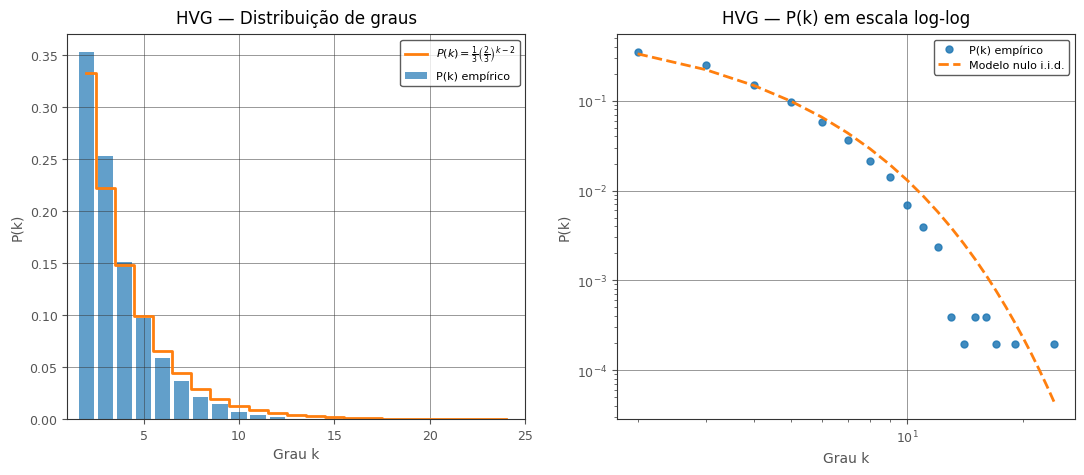

In [7]:
graus_hvg = np.array([
    grau for _, grau in G_hvg.degree()
])

k_range = np.arange(
    2,
    graus_hvg.max() + 1
)

p_emp = np.array([
    (graus_hvg == k).mean()
    for k in k_range
])

p_theo = (
    (1 / 3) *
    (2 / 3) ** (k_range - 2)
)

print(f"\n{'='*60}")
print("  VALIDAÇÃO P(k) — HVG VS. MODELO NULO")
print(f"{'='*60}")
print(f"Grau médio observado: {graus_hvg.mean():.4f}")
print("Grau médio teórico no limite i.i.d.: 4.0000")
print(
    f"Desvio em relação a 4: "
    f"{graus_hvg.mean() - 4.0:+.4f}"
)

print(f"\n{'k':>3} {'P_emp':>10} {'P_teórico':>12} {'Δ':>10}")
for k, pe, pt in zip(
    k_range[:12],
    p_emp[:12],
    p_theo[:12]
):
    print(
        f"{k:3d} {pe:10.4f} "
        f"{pt:12.4f} {pe - pt:+10.4f}"
    )

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    facecolor=FUNDO
)

for ax in axes:
    estilizar_ax(ax)

axes[0].bar(
    k_range,
    p_emp,
    color=AZUL,
    alpha=0.7,
    width=0.8,
    label="P(k) empírico"
)

axes[0].step(
    k_range,
    p_theo,
    where="mid",
    color=LARANJA,
    linewidth=2,
    label=r"$P(k)=\frac{1}{3}\left(\frac{2}{3}\right)^{k-2}$"
)

axes[0].set_xlim(
    1,
    min(30, k_range.max() + 1)
)
axes[0].set_xlabel("Grau k")
axes[0].set_ylabel("P(k)")
axes[0].set_title(
    "HVG — Distribuição de graus",
    pad=8
)
axes[0].legend(fontsize=8)

mascara_log = p_emp > 0

axes[1].loglog(
    k_range[mascara_log],
    p_emp[mascara_log],
    "o",
    color=AZUL,
    ms=5,
    alpha=0.85,
    label="P(k) empírico"
)

axes[1].loglog(
    k_range,
    p_theo,
    "--",
    color=LARANJA,
    lw=2,
    label="Modelo nulo i.i.d."
)

axes[1].set_xlabel("Grau k")
axes[1].set_ylabel("P(k)")
axes[1].set_title(
    "HVG — P(k) em escala log-log",
    pad=8
)
axes[1].legend(fontsize=8)

salvar_mostrar(
    fig,
    "parte1_validacao_pk.svg"
)

## 8 · Locais de visibilidade e comparação com ondas de calor

São mantidas as duas janelas de 21 dias usadas anteriormente:

- pico isolado em **26/11/2013**;
- onda de calor CTX90pct centrada em **15/03/2010**.

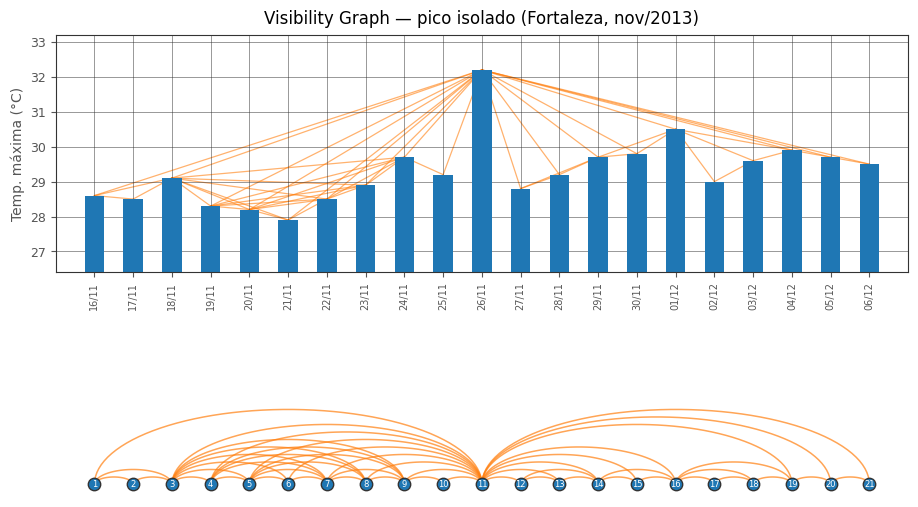

[OK] vg_exemplo_pico_isolado.svg — 52 arestas locais


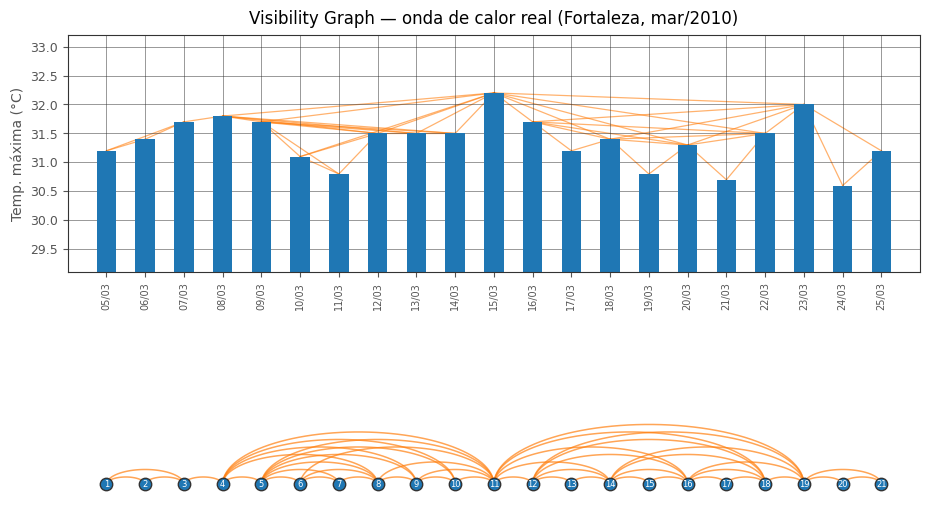

[OK] vg_exemplo_onda_calor.svg — 48 arestas locais


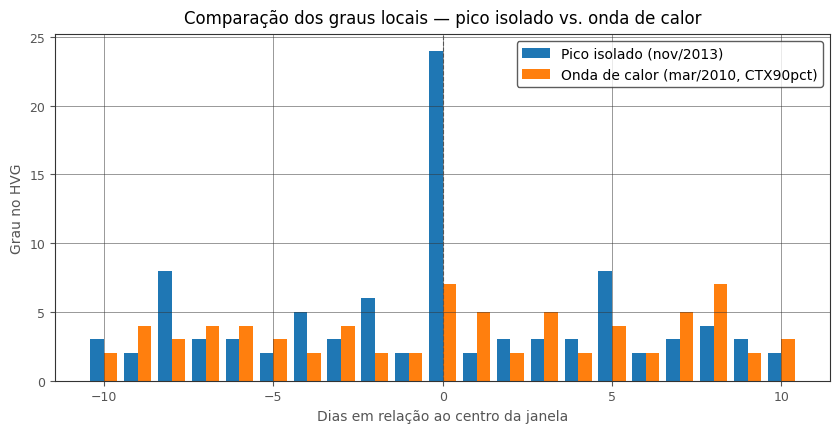

In [8]:
def idx_da_data(data):
    data = pd.Timestamp(data)
    indices = df_recorte.index[
        df_recorte["data"] == data
    ]

    if len(indices) == 0:
        raise ValueError(
            f"Data {data.date()} não encontrada no recorte."
        )

    return int(indices[0])


def plot_estilo_lacasa(
    indices,
    titulo,
    arquivo_svg,
    G
):
    n = len(indices)
    x = np.arange(n)
    y = serie_temp_max[indices]

    sub = G.subgraph(indices)
    mapa = {
        no_global: no_local
        for no_local, no_global in enumerate(indices)
    }

    arestas_locais = [
        (mapa[u], mapa[v])
        for u, v in sub.edges()
    ]

    fig, (ax_bar, ax_arc) = plt.subplots(
        2,
        1,
        figsize=(11, 6),
        height_ratios=[1.3, 1]
    )

    for ax in (ax_bar, ax_arc):
        estilizar_ax(ax)

    base = y.min() - 1.5

    ax_bar.bar(
        x,
        y - base,
        bottom=base,
        width=0.5,
        color=AZUL,
        zorder=2
    )

    for i, j in arestas_locais:
        ax_bar.plot(
            [x[i], x[j]],
            [y[i], y[j]],
            color=LARANJA,
            linewidth=0.9,
            alpha=0.6,
            zorder=1
        )

    ax_bar.set_xlim(-1, n)
    ax_bar.set_ylim(base, y.max() + 1)
    ax_bar.set_ylabel("Temp. máxima (°C)")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(
        [
            df_recorte["data"].iloc[i].strftime("%d/%m")
            for i in indices
        ],
        rotation=90,
        fontsize=7
    )
    ax_bar.set_title(titulo, pad=8)

    ax_arc.scatter(
        x,
        np.zeros(n),
        s=80,
        color=AZUL,
        edgecolor=BORDA,
        zorder=3
    )

    for posicao, lbl in enumerate(x):
        ax_arc.annotate(
            str(posicao + 1),
            (lbl, 0),
            ha="center",
            va="center",
            fontsize=6,
            zorder=4,
            color=FUNDO
        )

    for i, j in arestas_locais:
        centro = (x[i] + x[j]) / 2
        raio = abs(x[j] - x[i]) / 2
        theta = np.linspace(0, np.pi, 60)

        ax_arc.plot(
            centro + raio * np.cos(theta),
            raio * np.sin(theta) * 0.6,
            color=LARANJA,
            linewidth=1.1,
            alpha=0.7,
            zorder=2
        )

    ax_arc.set_xlim(-1, n)
    ax_arc.set_ylim(
        -0.5,
        (n / 2) * 0.6 + 0.5
    )
    ax_arc.axis("off")

    salvar_mostrar(
        fig,
        arquivo_svg
    )

    print(
        f"[OK] {arquivo_svg} — "
        f"{len(arestas_locais)} arestas locais"
    )


centro1 = idx_da_data("2013-11-26")
janela1 = list(range(centro1 - 10, centro1 + 11))

centro2 = idx_da_data("2010-03-15")
janela2 = list(range(centro2 - 10, centro2 + 11))

plot_estilo_lacasa(
    janela1,
    "Visibility Graph — pico isolado (Fortaleza, nov/2013)",
    "vg_exemplo_pico_isolado.svg",
    G_nvg
)

plot_estilo_lacasa(
    janela2,
    "Visibility Graph — onda de calor real (Fortaleza, mar/2010)",
    "vg_exemplo_onda_calor.svg",
    G_nvg
)

graus_hvg_dict = dict(G_hvg.degree())
offsets = np.arange(-10, 11)

fig, ax = plt.subplots(
    figsize=(10, 4.5)
)
estilizar_ax(ax)

largura = 0.4

ax.bar(
    offsets - largura / 2,
    [graus_hvg_dict[i] for i in janela1],
    width=largura,
    color=AZUL,
    label="Pico isolado (nov/2013)"
)

ax.bar(
    offsets + largura / 2,
    [graus_hvg_dict[i] for i in janela2],
    width=largura,
    color=LARANJA,
    label="Onda de calor (mar/2010, CTX90pct)"
)

ax.axvline(
    0,
    color=CINZA,
    linewidth=0.8,
    linestyle="--"
)

ax.set_xlabel("Dias em relação ao centro da janela")
ax.set_ylabel("Grau no HVG")
ax.set_title(
    "Comparação dos graus locais — pico isolado vs. onda de calor",
    pad=8
)
ax.legend()

salvar_mostrar(
    fig,
    "comparacao_hub_repulsion.svg"
)

## 9 · Série completa e grau dos nós

A série de temperatura máxima é representada juntamente com o grau do nó correspondente no HVG. A cor dos pontos representa o grau em escala logarítmica, permitindo localizar visualmente os dias de maior conectividade.

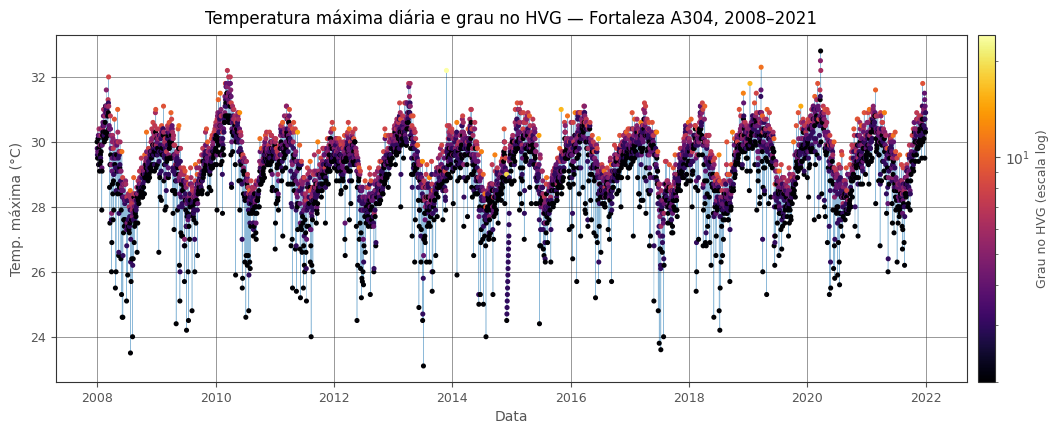

In [9]:
graus_hvg_arr = np.array([
    grau for _, grau in G_hvg.degree()
])

fig, ax = plt.subplots(
    figsize=(14, 4.5)
)
estilizar_ax(ax)

ax.plot(
    df_recorte["data"],
    serie_temp_max,
    color=AZUL,
    linewidth=0.4,
    alpha=0.5,
    zorder=1
)

sc = ax.scatter(
    df_recorte["data"],
    serie_temp_max,
    c=graus_hvg_arr,
    cmap="inferno",
    norm=mcolors.LogNorm(
        vmin=max(1, graus_hvg_arr.min()),
        vmax=graus_hvg_arr.max()
    ),
    s=7,
    zorder=2
)

cbar = plt.colorbar(
    sc,
    ax=ax,
    pad=0.01
)
cbar.set_label(
    "Grau no HVG (escala log)",
    color=CINZA,
    fontsize=9
)
cbar.ax.yaxis.set_tick_params(
    color=CINZA
)
plt.setp(
    cbar.ax.yaxis.get_ticklabels(),
    color=CINZA
)

ax.set_xlabel("Data")
ax.set_ylabel("Temp. máxima (°C)")
ax.set_title(
    "Temperatura máxima diária e grau no HVG — Fortaleza A304, 2008–2021",
    pad=8
)

salvar_mostrar(
    fig,
    "serie_completa_com_graus.svg"
)

# PARTE II — Análise Estrutural da Rede

Nesta etapa, HVG e NVG são analisados com as mesmas métricas para permitir comparação direta.

A densidade é

\[
\rho = \frac{2E}{N(N-1)}.
\]

A conectividade é verificada explicitamente, e a maior componente conexa é identificada. Para os Visibility Graphs construídos sobre a série completa, a conectividade esperada é preservada pelas conexões entre observações consecutivas.

In [10]:
def distribuicao_caminhos(G):
    """Distribuição de distâncias geodésicas, excluindo distância zero."""
    contagem = Counter()

    for no in G.nodes():
        contagem.update(
            nx.single_source_shortest_path_length(
                G,
                no
            ).values()
        )

    contagem.pop(0, None)
    return contagem


def componente_para_distancias(G):
    """
    Usa a rede inteira quando conectada.
    Se houver mais de uma componente, usa a maior componente conexa
    para calcular distâncias sem produzir métricas indefinidas.
    """
    if nx.is_connected(G):
        return G, 1.0

    componente = max(
        nx.connected_components(G),
        key=len
    )

    G_gigante = G.subgraph(
        componente
    ).copy()

    fracao = (
        G_gigante.number_of_nodes() /
        G.number_of_nodes()
    )

    return G_gigante, fracao


resultados = {}

for nome, G in (
    ("HVG", G_hvg),
    ("NVG", G_nvg)
):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    densidade = nx.density(G)

    componentes = list(
        nx.connected_components(G)
    )

    tamanhos = sorted(
        [len(c) for c in componentes],
        reverse=True
    )

    G_dist, fracao_gigante = componente_para_distancias(G)

    graus = np.array([
        grau for _, grau in G.degree()
    ])

    agrupamento_medio = nx.average_clustering(G)
    transitividade = nx.transitivity(G)

    valores_k, contagens_k = np.unique(
        graus,
        return_counts=True
    )

    p_k = contagens_k / contagens_k.sum()

    mascara_cauda = (
        (valores_k >= 5) &
        (p_k > 0)
    )

    if mascara_cauda.sum() >= 2:
        slope, _, r_value, _, _ = sp_stats.linregress(
            np.log(valores_k[mascara_cauda]),
            np.log(p_k[mascara_cauda])
        )
        alpha = -slope
        r2 = r_value ** 2
    else:
        alpha = np.nan
        r2 = np.nan

    contagem = distribuicao_caminhos(G_dist)
    n_pares = sum(contagem.values())

    media_caminho = (
        sum(
            distancia * quantidade
            for distancia, quantidade in contagem.items()
        ) / n_pares
    )

    diametro = max(contagem)

    resultados[nome] = {
        "N": N,
        "E": E,
        "densidade": densidade,
        "n_componentes": len(componentes),
        "tamanho_gigante": tamanhos[0],
        "fracao_gigante": fracao_gigante,
        "graus": graus,
        "agrupamento_medio": agrupamento_medio,
        "transitividade": transitividade,
        "contagem_caminhos": contagem,
        "media_caminho": media_caminho,
        "diametro": diametro,
        "alpha_cauda": alpha,
        "r2_cauda": r2,
    }

    print(f"\n{'='*60}")
    print(f"  PARTE II — {nome}")
    print(f"{'='*60}")
    print(f"Nós (N): {N}")
    print(f"Arestas (E): {E}")
    print(
        f"Densidade: {densidade:.8f} "
        f"({densidade * 100:.4f}%)"
    )
    print(f"Componentes conexas: {len(componentes)}")
    print(
        f"Maior componente: {tamanhos[0]} nós "
        f"({fracao_gigante * 100:.2f}% da rede)"
    )
    print(f"Grau médio: {graus.mean():.4f}")
    print(f"Grau mínimo: {graus.min()}")
    print(f"Grau máximo: {graus.max()}")
    print(
        f"Agrupamento médio <C>: "
        f"{agrupamento_medio:.4f}"
    )
    print(
        f"Transitividade: "
        f"{transitividade:.4f}"
    )
    print(
        f"Caminho mínimo médio <L>: "
        f"{media_caminho:.4f}"
    )
    print(f"Diâmetro D: {diametro}")

    if np.isfinite(alpha):
        print(
            f"Ajuste log-log da cauda (k >= 5): "
            f"alpha={alpha:.2f}; R²={r2:.3f}"
        )
    else:
        print(
            "Ajuste log-log da cauda: "
            "pontos insuficientes."
        )


  PARTE II — HVG
Nós (N): 5114
Arestas (E): 9287
Densidade: 0.00071034 (0.0710%)
Componentes conexas: 1
Maior componente: 5114 nós (100.00% da rede)
Grau médio: 3.6320
Grau mínimo: 2
Grau máximo: 24
Agrupamento médio <C>: 0.5417
Transitividade: 0.3055
Caminho mínimo médio <L>: 16.8318
Diâmetro D: 44
Ajuste log-log da cauda (k >= 5): alpha=5.01; R²=0.914

  PARTE II — NVG
Nós (N): 5114
Arestas (E): 16862
Densidade: 0.00128974 (0.1290%)
Componentes conexas: 1
Maior componente: 5114 nós (100.00% da rede)
Grau médio: 6.5944
Grau mínimo: 2
Grau máximo: 132
Agrupamento médio <C>: 0.7402
Transitividade: 0.3303
Caminho mínimo médio <L>: 5.7445
Diâmetro D: 11
Ajuste log-log da cauda (k >= 5): alpha=2.42; R²=0.943


## 10 · Distribuição de graus \(P(k)\): HVG e NVG

A distribuição de graus é comparada para as duas construções de Visibility Graph. A visualização principal usa escala log-log, conforme o objetivo de examinar a cauda e a presença de hubs.

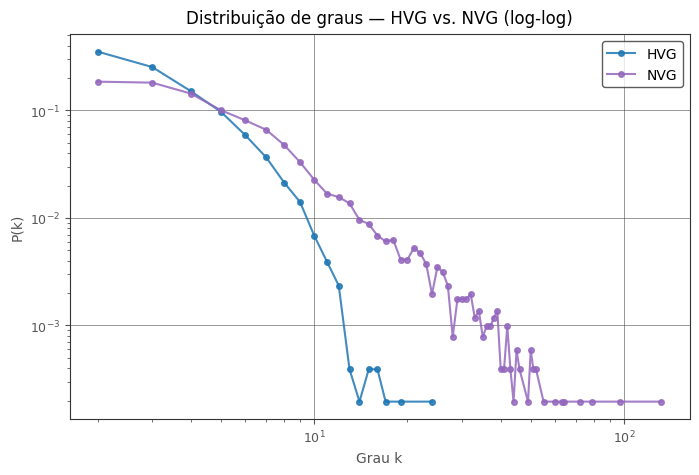

In [11]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)
estilizar_ax(ax)

for nome, cor in CORES_REDE.items():
    graus = resultados[nome]["graus"]

    valores, contagens = np.unique(
        graus,
        return_counts=True
    )

    pk = contagens / contagens.sum()

    mascara = (
        (valores > 0) &
        (pk > 0)
    )

    ax.loglog(
        valores[mascara],
        pk[mascara],
        "o-",
        color=cor,
        markersize=4,
        alpha=0.85,
        label=nome
    )

ax.set_xlabel("Grau k")
ax.set_ylabel("P(k)")
ax.set_title(
    "Distribuição de graus — HVG vs. NVG (log-log)",
    pad=8
)
ax.legend()

salvar_mostrar(
    fig,
    "parte2_distribuicao_grau_loglog.svg"
)

## 11 · Transitividade e coeficiente de agrupamento local

A **transitividade** é uma medida global baseada em triângulos e triplas conectadas. O **coeficiente de agrupamento local** \(C_i\) mede a conectividade entre os vizinhos de cada nó.

O gráfico \(C(k)\) versus \(k\) é mostrado para HVG e NVG. A curva \(C(k)=2/k\), já utilizada no desenvolvimento, é apresentada como referência de organização hierárquica.

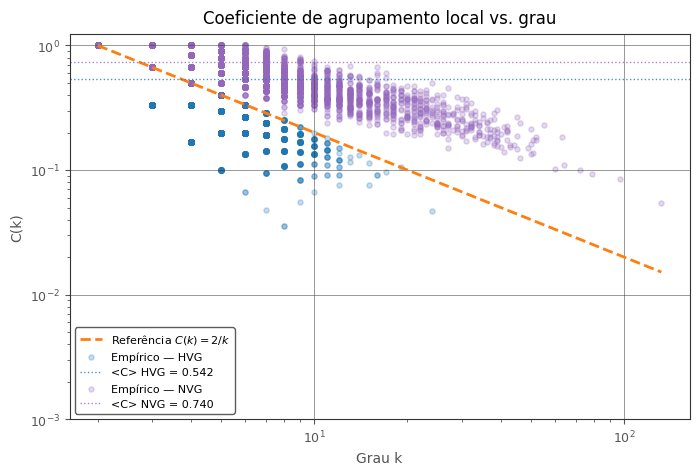

In [12]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)
estilizar_ax(ax)

k_max_global = max(
    resultados[nome]["graus"].max()
    for nome in resultados
)

k_teo = np.linspace(
    2,
    k_max_global,
    300
)

ax.loglog(
    k_teo,
    2 / k_teo,
    "--",
    color=LARANJA,
    linewidth=2,
    label=r"Referência $C(k)=2/k$"
)

for nome, cor in CORES_REDE.items():
    G = G_hvg if nome == "HVG" else G_nvg

    graus_dict = dict(G.degree())
    clustering_dict = nx.clustering(G)

    dados = [
        (graus_dict[no], clustering_dict[no])
        for no in G.nodes()
        if graus_dict[no] > 1
        and clustering_dict[no] > 0
    ]

    if dados:
        k_arr = np.array([
            item[0] for item in dados
        ])
        c_arr = np.array([
            item[1] for item in dados
        ])

        ax.scatter(
            k_arr,
            c_arr,
            alpha=0.25,
            s=14,
            color=cor,
            label=f"Empírico — {nome}"
        )

    ax.axhline(
        resultados[nome]["agrupamento_medio"],
        color=cor,
        linewidth=1,
        linestyle=":",
        alpha=0.8,
        label=(
            f"<C> {nome} = "
            f"{resultados[nome]['agrupamento_medio']:.3f}"
        )
    )

ax.set_xlabel("Grau k")
ax.set_ylabel("C(k)")
ax.set_title(
    "Coeficiente de agrupamento local vs. grau",
    pad=8
)
ax.set_ylim(bottom=1e-3)
ax.legend(fontsize=8)

salvar_mostrar(
    fig,
    "parte2_clustering_ck_vs_k.svg"
)

## 12 · Distâncias geodésicas, caminho mínimo médio e diâmetro

A distribuição dos comprimentos dos caminhos mais curtos é obtida por buscas em largura. A análise fornece:

- **\(\langle L\rangle\)**: comprimento médio do caminho mínimo;
- **\(D\)**: diâmetro, isto é, a maior distância geodésica encontrada.

Essas métricas descrevem a escala de separação topológica da rede. Valores de caminhos relativamente curtos em relação ao tamanho da rede são usados aqui como indicadores estruturais para a discussão do comportamento *small-world*; não se trata, neste notebook, de um teste estatístico independente contra uma rede aleatória.

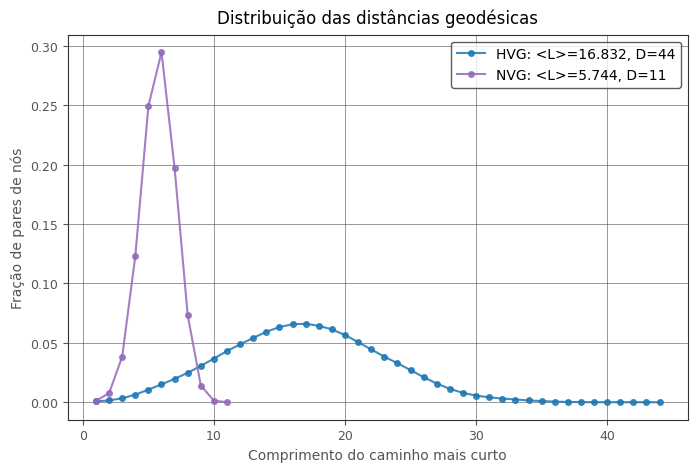

In [13]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)
estilizar_ax(ax)

for nome, cor in CORES_REDE.items():
    contagem = resultados[nome]["contagem_caminhos"]

    distancias = sorted(
        contagem.keys()
    )

    total = sum(
        contagem.values()
    )

    frequencias = [
        contagem[d] / total
        for d in distancias
    ]

    ax.plot(
        distancias,
        frequencias,
        "o-",
        color=cor,
        markersize=4,
        alpha=0.85,
        label=(
            f"{nome}: "
            f"<L>={resultados[nome]['media_caminho']:.3f}, "
            f"D={resultados[nome]['diametro']}"
        )
    )

ax.set_xlabel(
    "Comprimento do caminho mais curto"
)
ax.set_ylabel(
    "Fração de pares de nós"
)
ax.set_title(
    "Distribuição das distâncias geodésicas",
    pad=8
)
ax.legend()

salvar_mostrar(
    fig,
    "parte2_distancias_geodesicas.svg"
)

## 13 · Cruzamento físico-topológico: Top 15 hubs do HVG

Os nós são ordenados pelo grau no HVG. Para cada um dos 15 maiores hubs, são exibidos a data, a temperatura máxima e as flags `CTX90pct` e `EHF`.

A coincidência é considerada **estrita**: o nó conta como coincidência quando sua data pertence, sem aproximação temporal, a pelo menos um dos dois catálogos de ondas de calor já carregados.

In [14]:
def em_algum_evento(data, eventos):
    return any(
        (data >= evento.data_inicio) &
        (data <= evento.data_fim)
        for evento in eventos.itertuples()
    )


hubs_ordenados = sorted(
    G_hvg.degree(),
    key=lambda item: item[1],
    reverse=True
)

TOP_N = 15
linhas_hubs = []

for no, grau in hubs_ordenados[:TOP_N]:
    atributos = G_hvg.nodes[no]
    data_no = pd.Timestamp(
        atributos["data"]
    )

    ctx = em_algum_evento(
        data_no,
        eventos_ctx
    )

    ehf = em_algum_evento(
        data_no,
        eventos_ehf
    )

    linhas_hubs.append({
        "nó": no,
        "data": data_no.date(),
        "temp_max_°C": atributos["temp_max"],
        "grau": grau,
        "CTX90pct": ctx,
        "EHF": ehf,
        "coincide_onda": bool(ctx or ehf),
    })

tabela_hubs = pd.DataFrame(
    linhas_hubs
)

print(f"\n{'='*80}")
print(f"  TOP {TOP_N} HUBS DO HVG — CRUZAMENTO COM ONDAS DE CALOR")
print(f"{'='*80}")
print(
    tabela_hubs.to_string(
        index=False
    )
)

acertos = int(
    tabela_hubs["coincide_onda"].sum()
)

taxa_acerto = (
    acertos / TOP_N * 100
)

print(
    f"\nCoincidências estritas: "
    f"{acertos}/{TOP_N} "
    f"({taxa_acerto:.1f}%)"
)


  TOP 15 HUBS DO HVG — CRUZAMENTO COM ONDAS DE CALOR
  nó       data  temp_max_°C  grau  CTX90pct   EHF  coincide_onda
2156 2013-11-26         32.2    24     False False          False
2527 2014-12-02         29.0    19     False False          False
3094 2016-06-21         30.1    17     False False          False
2864 2015-11-04         31.0    16     False False          False
4029 2019-01-12         31.8    16     False False          False
1237 2011-05-22         30.3    15     False False          False
4343 2019-11-22         31.1    15     False False          False
2727 2015-06-20         30.2    14     False False          False
 880 2010-05-30         30.9    13      True False           True
2008 2013-07-01         29.4    13     False False          False
1362 2011-09-24         30.0    12     False False          False
2051 2013-08-13         28.9    12     False False          False
2220 2014-01-29         30.6    12     False False          False
2372 2014-06-30       

## 14 · Tabela-resumo da Parte II

A tabela reúne as métricas estruturais calculadas de forma única para HVG e NVG.

In [15]:
resumo_parte_ii = pd.DataFrame({
    "Métrica": [
        "Nós (N)",
        "Arestas (E)",
        "Densidade",
        "Componentes conexas",
        "Maior componente (nós)",
        "Grau médio <k>",
        "Grau máximo",
        "Agrupamento médio <C>",
        "Transitividade",
        "Caminho mínimo médio <L>",
        "Diâmetro (D)",
    ],
    "HVG": [
        resultados["HVG"]["N"],
        resultados["HVG"]["E"],
        resultados["HVG"]["densidade"],
        resultados["HVG"]["n_componentes"],
        resultados["HVG"]["tamanho_gigante"],
        resultados["HVG"]["graus"].mean(),
        resultados["HVG"]["graus"].max(),
        resultados["HVG"]["agrupamento_medio"],
        resultados["HVG"]["transitividade"],
        resultados["HVG"]["media_caminho"],
        resultados["HVG"]["diametro"],
    ],
    "NVG": [
        resultados["NVG"]["N"],
        resultados["NVG"]["E"],
        resultados["NVG"]["densidade"],
        resultados["NVG"]["n_componentes"],
        resultados["NVG"]["tamanho_gigante"],
        resultados["NVG"]["graus"].mean(),
        resultados["NVG"]["graus"].max(),
        resultados["NVG"]["agrupamento_medio"],
        resultados["NVG"]["transitividade"],
        resultados["NVG"]["media_caminho"],
        resultados["NVG"]["diametro"],
    ],
})

print(
    resumo_parte_ii.to_string(
        index=False
    )
)

                 Métrica         HVG          NVG
                 Nós (N) 5114.000000  5114.000000
             Arestas (E) 9287.000000 16862.000000
               Densidade    0.000710     0.001290
     Componentes conexas    1.000000     1.000000
  Maior componente (nós) 5114.000000  5114.000000
          Grau médio <k>    3.631991     6.594447
             Grau máximo   24.000000   132.000000
   Agrupamento médio <C>    0.541678     0.740219
          Transitividade    0.305523     0.330317
Caminho mínimo médio <L>   16.831819     5.744484
            Diâmetro (D)   44.000000    11.000000
